Bibi Ekhkla Hashimi   
 202411435

In [2]:
from google.colab import files
uploaded= files.upload()

import pandas as pd
df=pd.read_csv('heart.csv')
df.head()

Saving heart.csv to heart.csv


,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
from sklearn.preprocessing import LabelEncoder

# Gender M or F
# encoder = 0 or 1

encoder= LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
  df[col]=encoder.fit_transform(df[col])

df

x=df.drop('HeartDisease',axis=1)
y=df['HeartDisease']

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2, random_state=1)

Accuracy 0.8641304347826086


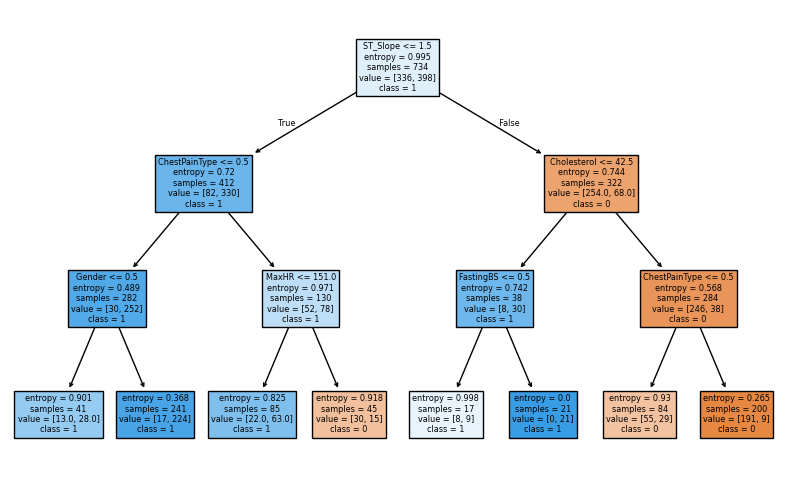

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree= DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)
tree.fit(x_train,y_train)

y_pred_tree=tree.predict(x_test)
accuracy_tree = accuracy_score(y_test,y_pred_tree)
print("Accuracy", accuracy_tree)

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10,6))
plot_tree(tree,filled=True,feature_names=x.columns,class_names=['0','1'])
plt.show()

In [7]:
#svm
from sklearn import svm
svm_classifiers=svm.SVC(kernel='linear')
svm_classifiers.fit(x_train,y_train)
y_pred_svm=svm_classifiers.predict(x_test)
accuracy_svm=accuracy_score(y_test,y_pred_svm)
print("Accuracy SVM:", accuracy_svm)


Accuracy SVM: 0.9130434782608695
